In [7]:
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [8]:
# 1. Load Model & Meta
data = joblib.load('ciciot_lightgbm_model.pkl')
model = data['model']
mapping = data['label_mapping']
dropped = data['cols_to_drop']
inv_mapping = {v: k for k, v in mapping.items()}


In [9]:
# 2. Load and Process Test Data
# Re-using the logic from Phase 3 but for test.csv
dict_8classes = {
    'DDoS-VSE': 'DDoS', 'DDoS-UDP_Flood': 'DDoS', 'DDoS-UDP_Fragmentation': 'DDoS', 'DDoS-TCP_Flood': 'DDoS', 
    'DDoS-SYN_Flood': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS', 'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-ICMP_Flood': 'DDoS',
    'DDoS-ICMP_Fragmentation': 'DDoS', 'DDoS-HTTP_Flood': 'DDoS', 'DDoS-SlowLoris': 'DDoS',
    'DoS-UDP_Flood': 'DoS', 'DoS-SYN_Flood': 'DoS', 'DoS-TCP_Flood': 'DoS', 'DoS-HTTP_Flood': 'DoS',
    'Mirai-greeth_flood': 'Mirai', 'Mirai-greip_flood': 'Mirai', 'Mirai-udpplain': 'Mirai',
    'Recon-HostDiscovery': 'Recon', 'Recon-OSScan': 'Recon', 'Recon-PortScan': 'Recon', 'Recon-PingSweep': 'Recon',
    'VulnerabilityScan': 'Recon', 'SqlInjection': 'Web', 'BrowserHijacking': 'Web', 'CommandInjection': 'Web',
    'Backdoor_Detection': 'Web', 'XSS': 'Web', 'Dictionary_Attack': 'Brute Force', 'Uploading_Attack': 'Brute Force',
    'DNS_Spoofing': 'Spoofing', 'MITM_ARP_Spoofing': 'Spoofing', 'BenignTraffic': 'Benign'
}
chunks = pd.read_csv('test.csv', chunksize=500000)
test_list = []
for chunk in chunks:
    chunk['label'] = chunk['label'].map(dict_8classes)
    chunk = chunk.dropna(subset=['label'])
    test_list.append(chunk)

test_df = pd.concat(test_list)
X_test = test_df.drop('label', axis=1).drop(columns=dropped)
y_test = test_df['label'].map(mapping)


In [10]:
# 3. Predict
y_pred = model.predict(X_test)

In [11]:

# 4. Final Evaluation
print(f"FINAL TEST ACCURACY: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=list(mapping.keys())))


FINAL TEST ACCURACY: 0.9941

Classification Report:
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00    758209
       Mirai       1.00      1.00      1.00     66749
         DoS       1.00      1.00      1.00    204245
      Benign       0.97      0.89      0.93     27709
       Recon       0.80      0.78      0.79      8812
    Spoofing       0.66      0.81      0.73      4570
         Web       0.17      0.62      0.26       504
 Brute Force       0.10      0.03      0.05        33

    accuracy                           0.99   1070831
   macro avg       0.71      0.77      0.72   1070831
weighted avg       1.00      0.99      0.99   1070831



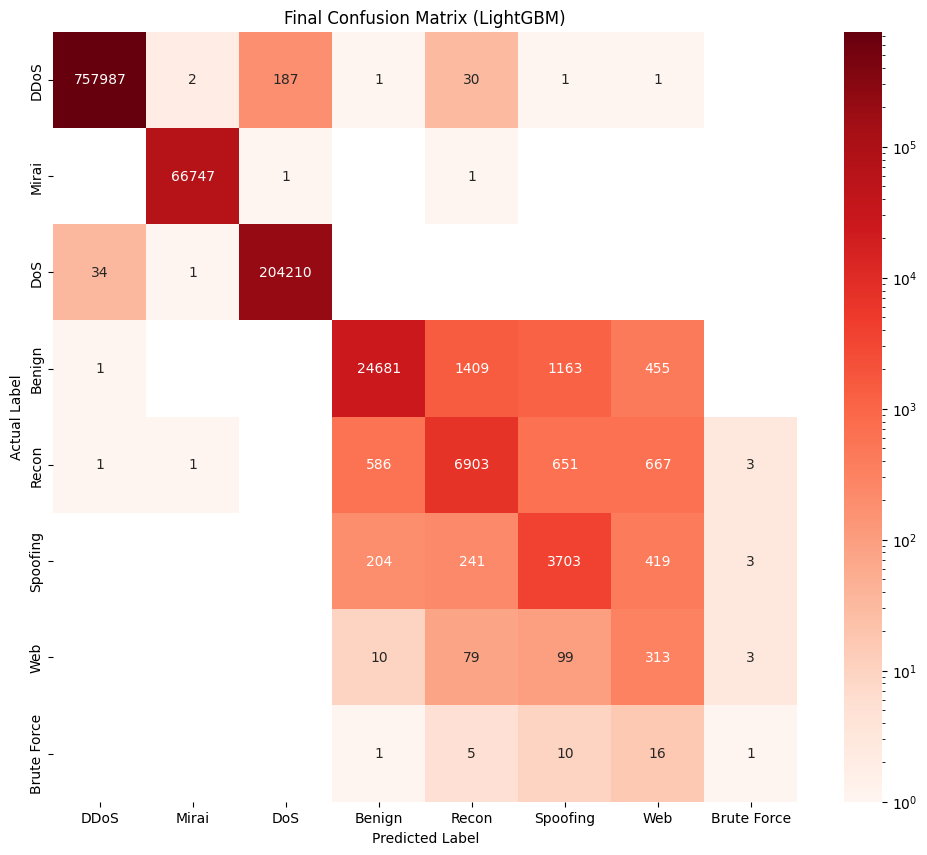

In [12]:
# 5. Confusion Matrix
from matplotlib.colors import LogNorm


plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', norm=LogNorm(),
            xticklabels=list(mapping.keys()), 
            yticklabels=list(mapping.keys()))
plt.title('Final Confusion Matrix (LightGBM)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()